In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

XENIUM_DATA_DIR = PROJECT_DATA_DIR
DATASET_NAME = 'Primary_Dermal_Melanoma'
DATA_DIR = f'{XENIUM_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# This is for loading the coefficients into the adata, which requires spacetravlr to be installed (or at least some of its required arrays)

# adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
# adata

# from metab_processing.SpaceTravLR import beta_analysis

# betadata_dir = f'{DATA_DIR}/spacetravlr_output/betadata'
# beta_analysis.betas_to_adata(adata, betadata_dir, group=None)
# print(adata)
# adata.write_h5ad(f"{DATA_DIR}/spacetravlr_adata.h5ad")
# del adata

In [4]:
adata = sc.read_h5ad(f'{DATA_DIR}/all_metab_spacetravlr_adata.h5ad')
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'sub_cluster_5_res_1', 'sub_cluster_5_res_0.75', 'sub_cluster_5_res_0.5', 'sub_cluster_5_res_0.37', 'sub_cluster_5_res_0.25', 'sub_cluster_5_res_0.15', 'sub_cluster_5_res_0.1', 'sub_cluster_5_res_0.05', 'sub_cluster_2_res_1', 'sub_cluster_2_res_0.75', 'sub_cluster_2_res_0

/tmp/ipykernel_3904482/4166114895.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='Tier3');


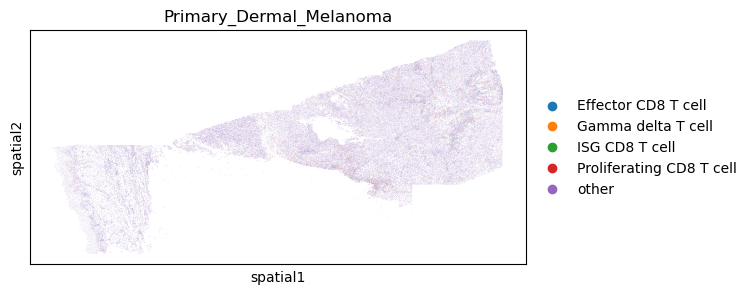

In [5]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='Tier3');

/tmp/ipykernel_3904482/679526146.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


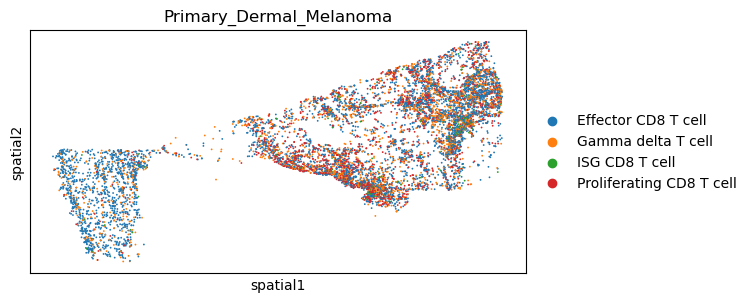

In [6]:
sc.pl.spatial(
    adata[adata.obs['Tier3'] != 'other'], 
    spot_size=35, 
    show=False, 
    title=DATASET_NAME, 
    color='Tier3'
);

In [7]:
list(adata.uns['beta_modulators'])

['CD3E',
 'CD3G',
 'CD4',
 'CTLA4',
 'ENTPD1',
 'FOXP3',
 'HAVCR2',
 'HIF1A',
 'IL10',
 'IL2RA',
 'LAG3',
 'MYC',
 'PDCD1',
 'TBP',
 'TCF7',
 'TOX']

In [8]:
GENE = 'CD3E'
adata.uns['beta_modulators'][GENE]

array(['ARID3B', 'BCL6', 'BCL6B', 'CTCF', 'EHF', 'ELK4', 'EP300', 'ESRRA',
       'ETV5', 'FLI1', 'FOXA1', 'FOXD2', 'FOXI1', 'FOXJ2', 'FOXL2',
       'FOXO1', 'FOXO3', 'FOXO4', 'GATA1', 'GATA2', 'GATA3', 'HOXA5',
       'HOXB4', 'HOXB6', 'HOXB7', 'HOXB9', 'IRX1', 'MECOM', 'MEF2A',
       'MYEF2', 'NR3C1', 'PDX1', 'PITX1', 'POU1F1', 'POU2F1', 'PPARGC1A',
       'RUNX1', 'SIN3A', 'SMAD4', 'STAT1', 'STAT3', 'STAT5A', 'STAT5B',
       'TCF7L2', 'THRA', 'THRB', 'ZBTB1', 'TGFB1$TGFBR1', 'TGFB1$TGFBR2',
       'TGFB2$TGFBR2', 'TGFB3$TGFBR1', 'TGFB3$TGFBR2', 'TGFB3$ACVR1',
       'BMP7$BMPR2', 'BMP8A$BMPR2', 'BMP8B$ACVR1', 'BMP8B$ACVR2A',
       'BMP8B$BMPR2', 'BMP8B$BMPR1A', 'GDF11$TGFBR1', 'GDF11$ACVR2A',
       'GDF11$ACVR1B', 'GDF15$TGFBR2', 'INHBA$ACVR1B', 'INHBA$ACVR2A',
       'WNT2$FZD1', 'WNT2$LRP5', 'WNT3$FZD1', 'WNT3$FZD10', 'WNT3$FZD4',
       'WNT2$LRP6', 'WNT3$LRP6', 'WNT5A$FZD1', 'WNT5A$FZD10',
       'WNT5A$FZD4', 'WNT5A$FZD6', 'WNT5A$MCAM', 'FGF1$FGFR1',
       'FGF2$FGFR1', '

In [9]:
GENE = 'HIF1A'
adata.uns['beta_modulators'][GENE]

array(['AR', 'ARID3B', 'ARNT', 'ARNTL', 'ATF3', 'BARHL2', 'BRCA1',
       'CLOCK', 'E2F1', 'E2F3', 'E2F4', 'EGR2', 'EGR3', 'EGR4', 'ELK4',
       'EMX2', 'EP300', 'ESR1', 'ESR2', 'ESRRA', 'ETS1', 'FOXA1', 'FOXA2',
       'FOXD2', 'FOXE1', 'FOXE3', 'FOXI1', 'FOXJ2', 'FOXL2', 'FOXN1',
       'FOXO1', 'FOXO3', 'FOXO4', 'GATA1', 'GATA2', 'GATA3', 'GMEB2',
       'HDAC2', 'HES1', 'HES4', 'HEY1', 'HLX', 'ID4', 'IRF1', 'IRF3',
       'KLF12', 'KLF4', 'KLF5', 'MAX', 'MEF2A', 'MEF2C', 'MITF', 'MLXIP',
       'MLXIPL', 'MYC', 'MYCN', 'NANOG', 'NFATC1', 'NKX2-3', 'NKX2-4',
       'NR2C2', 'NR2E3', 'NR3C1', 'NRF1', 'OSR2', 'PAX1', 'PAX5', 'PAX8',
       'PBX3', 'POLR2A', 'POU2F2', 'POU5F1', 'PPARA', 'PPARD', 'PPARG',
       'PRDM1', 'RFX2', 'RFX4', 'RFX5', 'RREB1', 'RXRA', 'SETDB1',
       'SIN3A', 'SIRT6', 'SMAD1', 'SP1', 'SP3', 'SP9', 'SRF', 'STAT1',
       'STAT3', 'TAF1', 'TAL1', 'TBP', 'TCFL5', 'USF1', 'WT1', 'YY1',
       'ZBTB33', 'ZEB1', 'ZFP57', 'ZNF281', 'ZNF341', 'ZNF683',
       'TGFB1

In [10]:
def plot_beta(adata, gene, modulator, tier, cell_types=None, spot_size=35):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    sub.obs['beta'] = sub.obsm[f'beta_{gene}'][:, i]
    sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
                  title=f'{gene} ~ {modulator} ({tier})')

/tmp/ipykernel_3904482/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3904482/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,
/tmp/ipykernel_3904482/4168805372.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sub, color='beta', spot_size=spot_size, show=False,


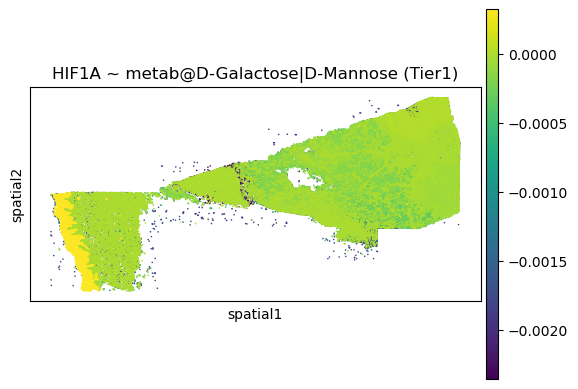

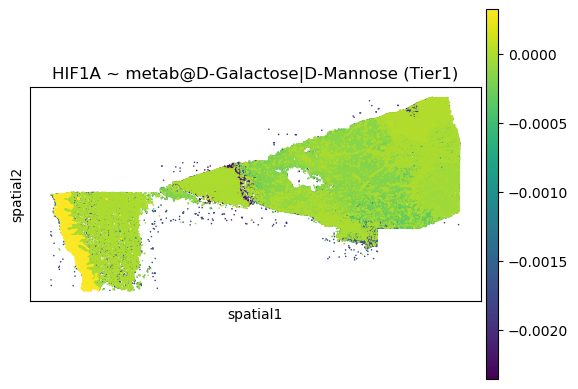

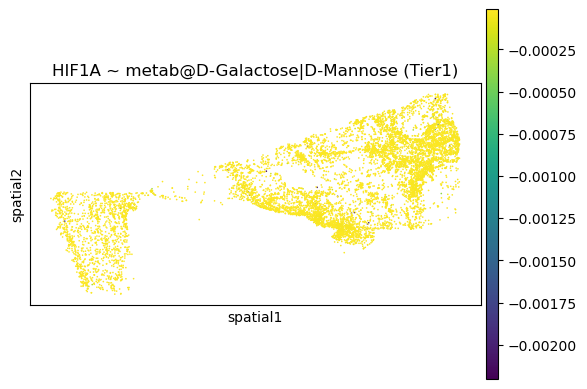

In [11]:
gp = [m for m in adata.uns['beta_modulators'][GENE] if '@' in m][1]
plot_beta(adata, GENE, gp, 'Tier1', ['T Cell', 'other'])
plot_beta(adata, GENE, gp, 'Tier1', ['other'])
plot_beta(adata, GENE, gp, 'Tier1', ['T Cell'])

In [12]:
adata.uns['beta_modulators']['FOXP3'] # Note that this demonstrates that we have no metabolite gene pairs (indicated with @),
# ie all the gps were zeroed out in training. This also shows that if we have a beta_modulator, then it is non zero on some cell

array(['AR', 'BCL3', 'CTCF', 'CTCFL', 'EBF1', 'EGR2', 'EGR3', 'EGR4',
       'ESR2', 'FOXA1', 'FOXD2', 'FOXE1', 'FOXE3', 'FOXI1', 'FOXL2',
       'GATA2', 'GATA3', 'HDAC2', 'HIVEP2', 'KLF5', 'MAX', 'NFATC1',
       'NFATC2', 'NFATC3', 'NFATC4', 'NFKB1', 'NR3C1', 'NR3C2', 'NRF1',
       'PAX5', 'PAX7', 'PGR', 'POU5F1', 'RBPJ', 'REL', 'REST', 'RFX1',
       'RXRA', 'SMC3', 'SOX18', 'SRF', 'TAL1', 'TBX2', 'TBX21', 'TBX4',
       'TBX5', 'TP63', 'ZIC4', 'ZNF281', 'TGFB1$TGFBR2', 'TGFB3$TGFBR1',
       'TGFB3$TGFBR2', 'BMP8B$BMPR2', 'GDF15$TGFBR2', 'INHBA$ACVR2A',
       'WNT2$FZD1', 'WNT5A$FZD1', 'FGF1$FGFR1', 'FGF2$FGFR1',
       'FGF7$FGFR1', 'PDGFA$PDGFRA', 'PDGFA$PDGFRB', 'PDGFB$PDGFRA',
       'PDGFB$PDGFRB', 'PDGFC$PDGFRA', 'PDGFD$PDGFRB', 'CCL8$CCR1',
       'CCL13$CCR1', 'CCL8$CCR2', 'CCL22$CCR4', 'CXCL9$CXCR3',
       'CXCL10$CXCR3', 'CXCL11$CXCR3', 'CXCL13$CXCR3', 'CXCL12$CXCR4',
       'CXCL11$ACKR3', 'CXCL12$ACKR3', 'CXCL16$CXCR6', 'IL7$IL2RG',
       'IL15$IL2RB', 'IL15$IL2RG'

In [13]:
def get_betas_modulator(adata, gene, modulator, tier=None, cell_types=None):
    i = (adata.uns['beta_modulators'][gene] == modulator).argmax()
    sub = adata if cell_types is None else adata[adata.obs[tier].isin(cell_types)]
    sub = sub[:, :1].copy()
    return sub.obsm[f'beta_{gene}'][:, i]

def agg_modulator(adata, gene, modulator, tier=None, cell_types=None):
    betas = get_betas_modulator(adata, gene, modulator, tier, cell_types)
    return np.mean(betas), np.std(betas)

agg_modulator(adata, GENE, 'NFKB1', 'Tier3', cell_types=['Effector CD8 T cell'])
        

(np.float32(0.029200157), np.float32(0.04516347))

In [14]:
harr_data_path = f'{DATA_DIR}/easy_download/harreman_outputs/[ccc_results][cell_com_df_m].csv'
harr_data = pd.read_csv(harr_data_path)
harr_data

,Unnamed: 0,Metabolite,C_p,Z,Z_pval,Z_FDR,C_np,pval_np,FDR_np,selected
0,0,"(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3...",24222.138518,3.927060,4.299528e-05,5.459718e-05,342.958304,0.034965,0.039397,True
1,1,17a-Ethynylestradiol,43819.621576,10.091085,3.024862e-24,7.014172e-24,21144.959794,0.000999,0.001390,True
2,2,"1b,3a,12a-Trihydroxy-5b-cholanoic acid",24222.138518,3.927060,4.299528e-05,5.459718e-05,342.958304,0.034965,0.039397,True
3,3,2-Hydroxychlorpropamide,52434.216429,22.866124,5.050912e-116,2.606922e-115,13055.938043,0.000999,0.001390,True
4,4,25-Hydroxycholesterol,35418.246732,34.801781,1.142963e-265,9.624950e-265,236939.994767,0.000999,0.001390,True
...,...,...,...,...,...,...,...,...,...,...
155,155,Vitamin D3,61675.852746,60.602366,0.000000e+00,0.000000e+00,137797.367094,0.000999,0.001390,True
156,156,Water,96242.781163,12.132474,3.553479e-34,1.093378e-33,71691.275964,0.000999,0.001390,True
157,157,Zinc,61728.318371,27.271790,4.583938e-164,2.820885e-163,52473.577489,0.000999,0.001390,True
158,158,alpha-Ketoisovaleric acid,12520.976488,12.303045,4.361137e-35,1.368200e-34,76253.540782,0.000999,0.001390,True


In [15]:
def _modulator_members(modulator):
    """'metab@A|B|C' -> ['A', 'B', 'C'] (exact whole-metabolite names)."""
    name = modulator.split('@', 1)[1] if '@' in modulator else modulator
    return name.split('|')


def mean_abs_coeff(adata, TARGET_GENE, modulator):
    betas = get_betas_modulator(adata, TARGET_GENE, modulator)
    return np.mean(np.abs(betas)), np.std(betas)


def extract_betas(TARGET_GENE, adata):
    """One row per metabolite: avg |β|, β std, and both FDRs. Returns a DataFrame."""
    modulators = adata.uns['beta_modulators'][TARGET_GENE]
    rows = []

    for metab in harr_data['Metabolite']:
        # EXACT membership, not substring: 'Adenosine' no longer matches
        # 'Adenosine triphosphate' or 'Adenosine diphosphate ribose'.
        match = [m for m in modulators if metab in _modulator_members(m)]

        if len(match) > 1:
            print(f"WARNING: {metab} matched multiple modulators: {match}")
            continue
        elif len(match) == 0:
            avg_coeff, std_coeff = 0.0, np.nan
        else:
            avg_coeff, std_coeff = mean_abs_coeff(adata, TARGET_GENE, match[0])

        h = harr_data.loc[harr_data['Metabolite'] == metab].iloc[0]
        rows.append({
            'metabolite': metab,
            'avg_coeff': avg_coeff,
            'std_coeff': std_coeff,
            'FDR_np': float(h['FDR_np']),
            'Z_FDR': float(h['Z_FDR']),
        })

    return pd.DataFrame(rows)


def plot_betas(df, fdr_col='Z_FDR', TARGET_GENE='', ax=None,
               labels=True, xlim=None, ylim=None):
    """Scatter avg |β| vs -log10(FDR). Set labels=False to hide text;
    pass xlim/ylim tuples to zoom."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x = df['avg_coeff'].to_numpy()
    y = -np.log10(df[fdr_col].to_numpy())

    ax.scatter(x, y, s=30, alpha=0.8)
    ax.axhline(-np.log10(0.05), ls='--', lw=1, color='grey', label='FDR = 0.05')
    ax.axvline(0, ls=':', lw=1, color='grey')
    ax.set_xlabel('Average |modulator coefficient| (|β|)')
    ax.set_ylabel(f'-log10({fdr_col})')
    ax.set_title(f'{TARGET_GENE}: {fdr_col} vs avg |β|')
    ax.legend()

    if labels:
        for m, xi, yi in zip(df['metabolite'], x, y):
            if xi != 0:
                ax.annotate(m, (xi, yi), fontsize=7,
                            xytext=(3, 3), textcoords='offset points')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return ax

fdr_vs_bata_df = extract_betas('CD3E', adata)

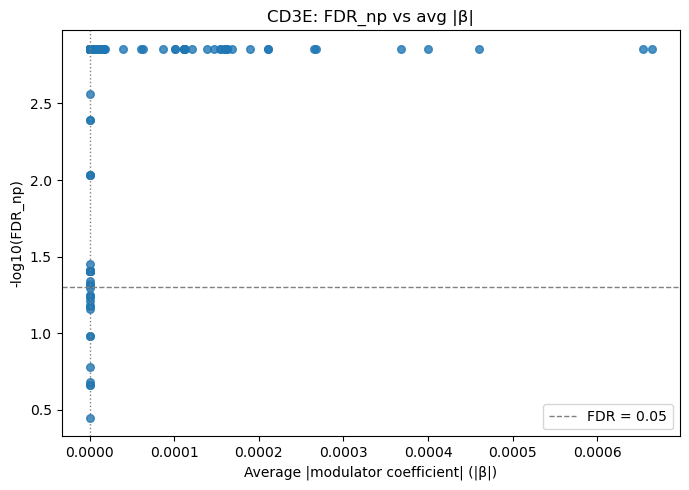

/tmp/ipykernel_3904482/1519205775.py:50: RuntimeWarning: divide by zero encountered in log10
  y = -np.log10(df[fdr_col].to_numpy())


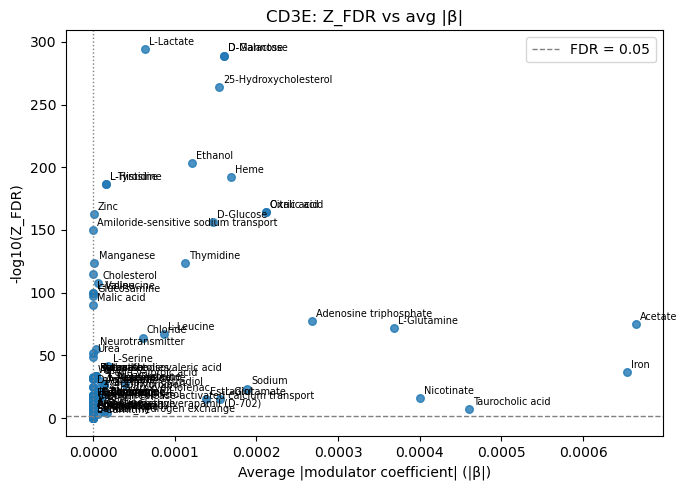

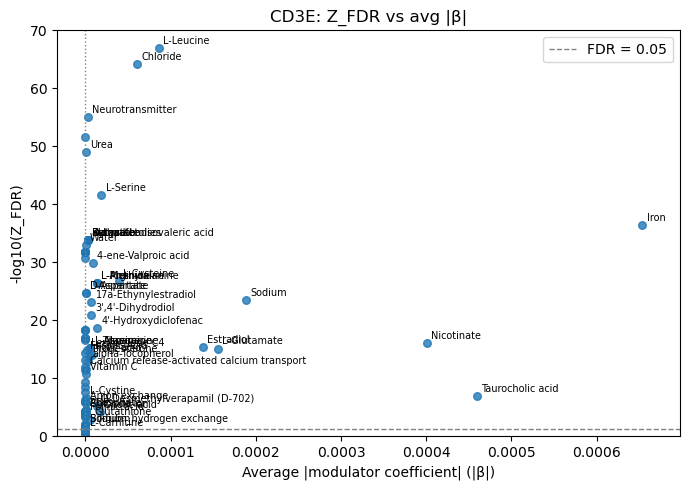

In [16]:
plot_betas(fdr_vs_bata_df, fdr_col='FDR_np', labels=False, TARGET_GENE='CD3E')
plt.tight_layout()
plt.show()

plot_betas(fdr_vs_bata_df, fdr_col='Z_FDR', TARGET_GENE='CD3E')
plt.tight_layout()
plt.show()

# zoom in on the crowded region near the x-axis, no labels
plot_betas(fdr_vs_bata_df, fdr_col='Z_FDR', TARGET_GENE='CD3E', ylim=(0, 70))
plt.tight_layout()
plt.show()

In [22]:
def extract_betas_all(target_genes, adata):
    """{gene: DataFrame} — one extract_betas result per target gene."""
    return {gene: extract_betas(gene, adata) for gene in target_genes}


def plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False, ncols=3,
                    xlim=None, ylim=None, figsize=None):
    """Plot every gene's df in a grid. `dfs` is the {gene: DataFrame} dict."""
    genes = list(dfs)
    ncols = min(ncols, len(genes))
    nrows = -(-len(genes) // ncols)  # ceil
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, gene in zip(axes, genes):
        plot_betas(dfs[gene], fdr_col=fdr_col, TARGET_GENE=gene, ax=ax,
                   labels=labels, xlim=xlim, ylim=ylim)

    for ax in axes[len(genes):]:  # hide unused panels
        ax.axis('off')

    fig.tight_layout()
    return fig, axes

genes = list(adata.uns['beta_modulators'])
dfs = extract_betas_all(genes, adata)

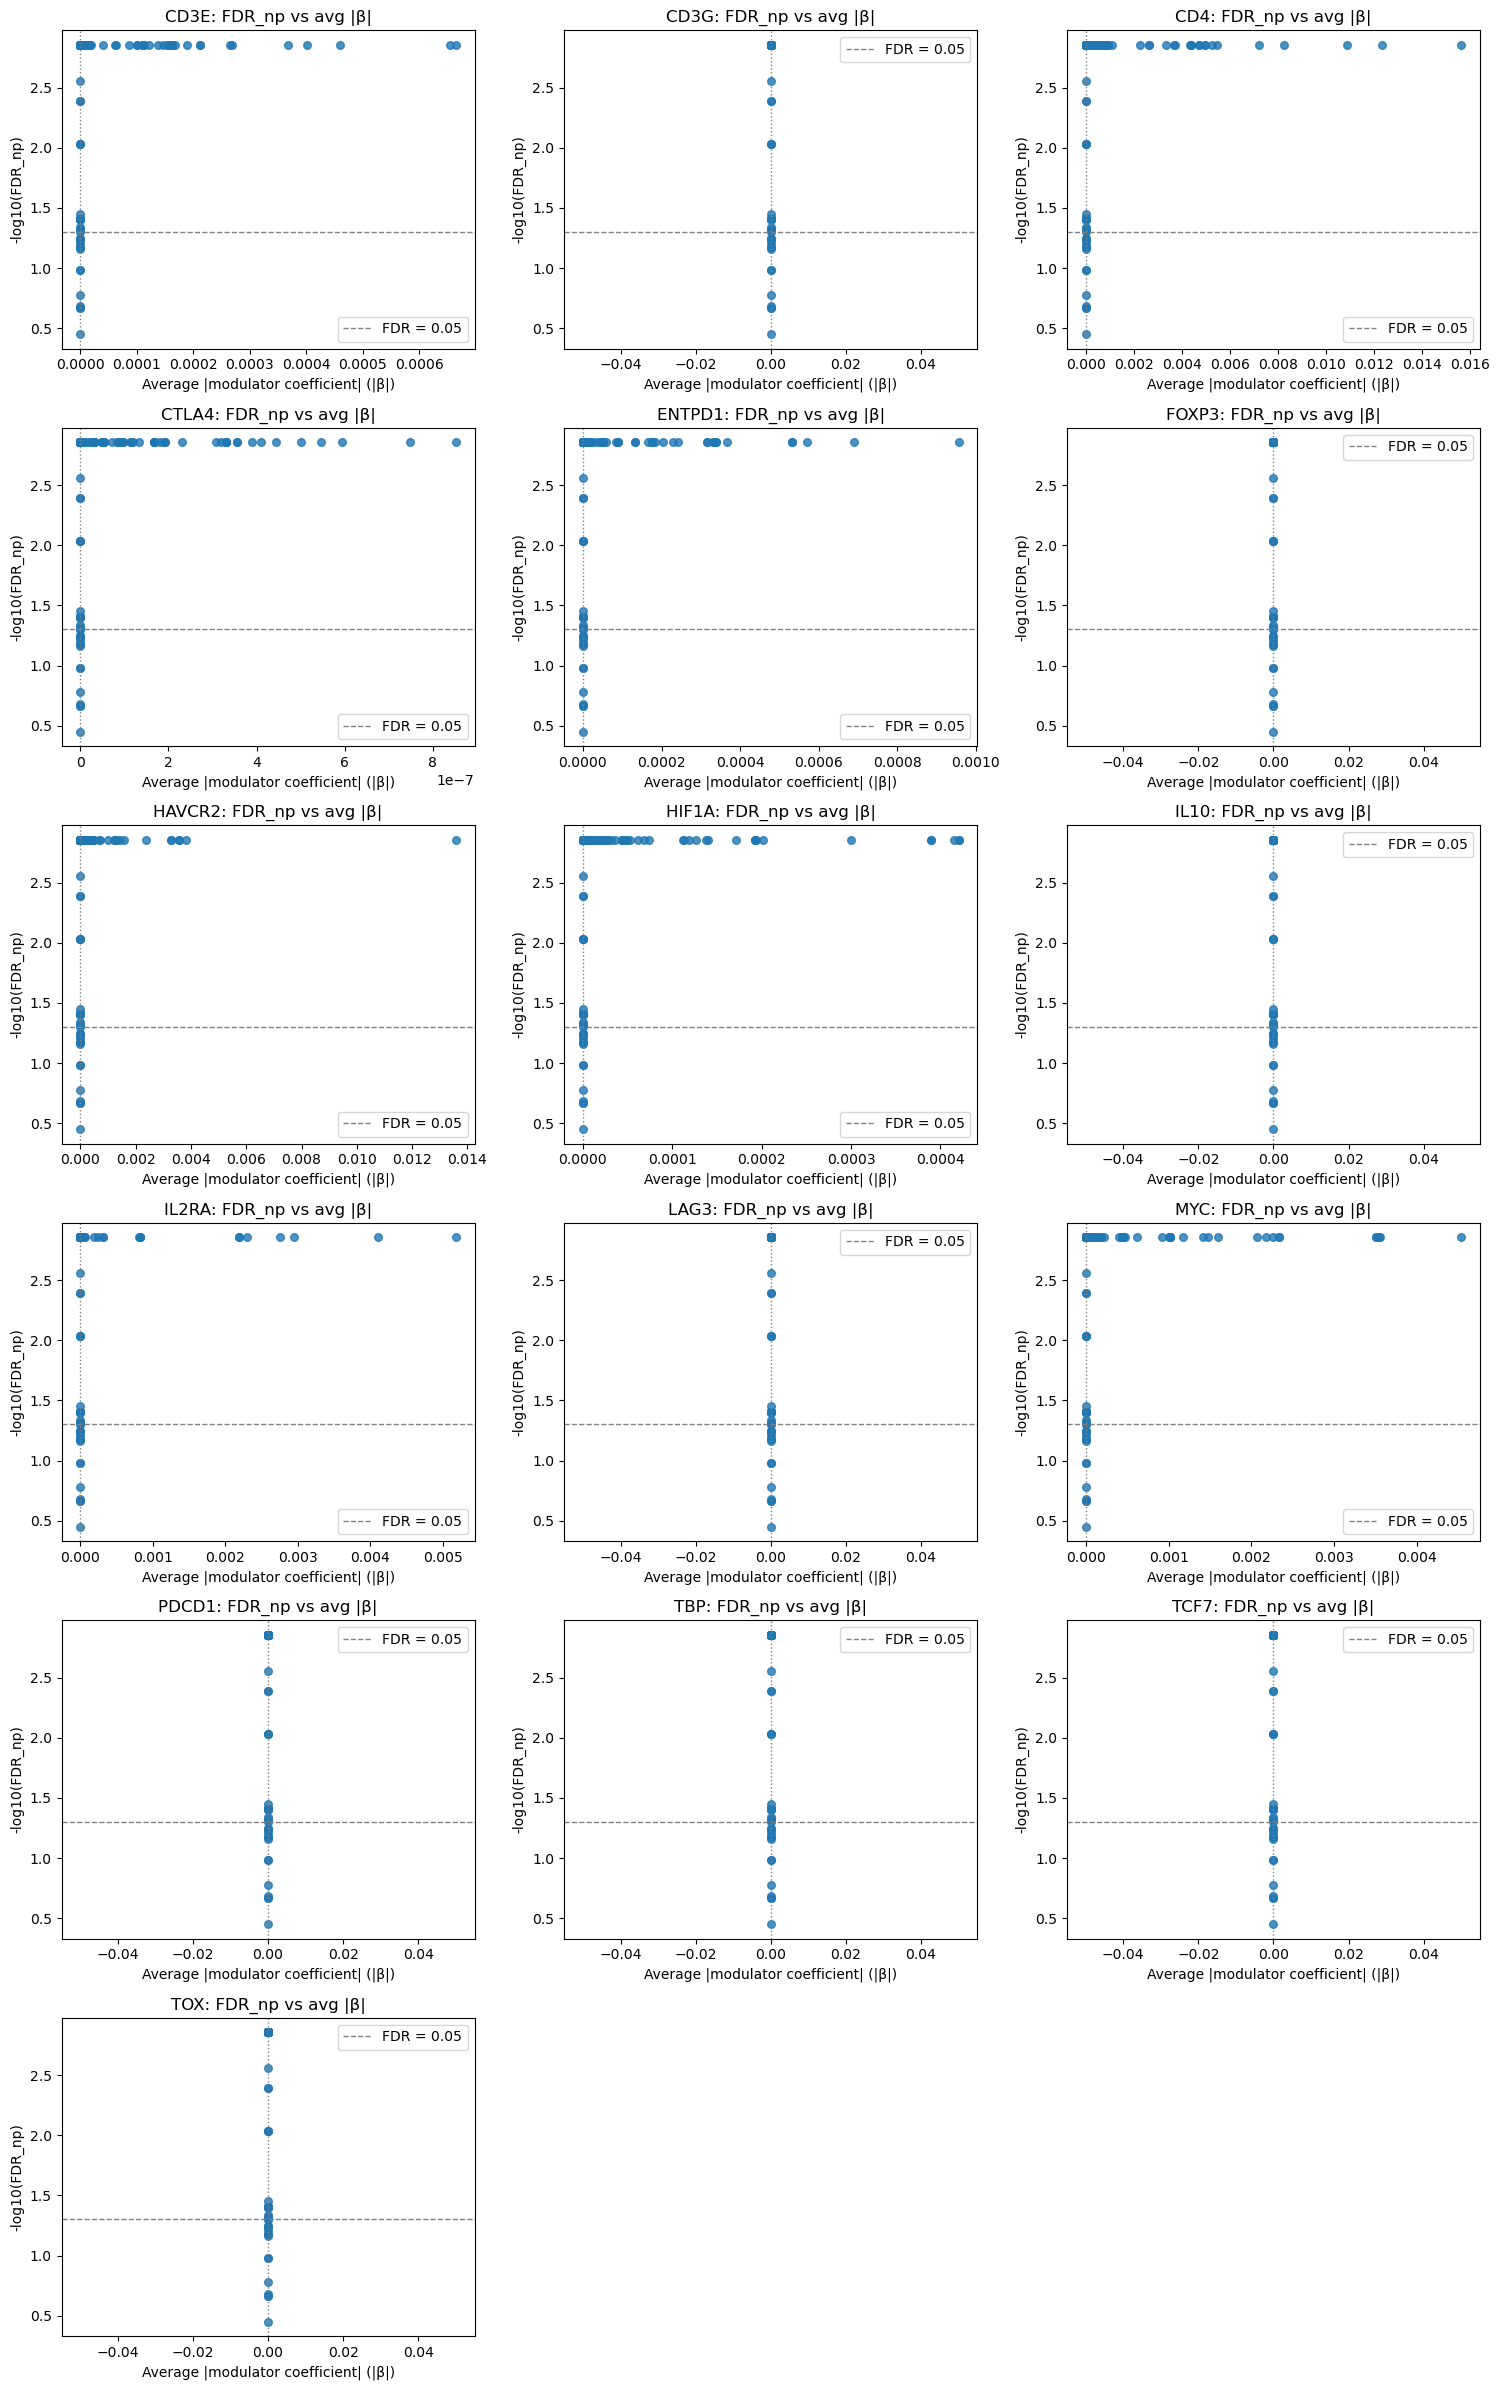

/tmp/ipykernel_3904482/1519205775.py:50: RuntimeWarning: divide by zero encountered in log10
  y = -np.log10(df[fdr_col].to_numpy())


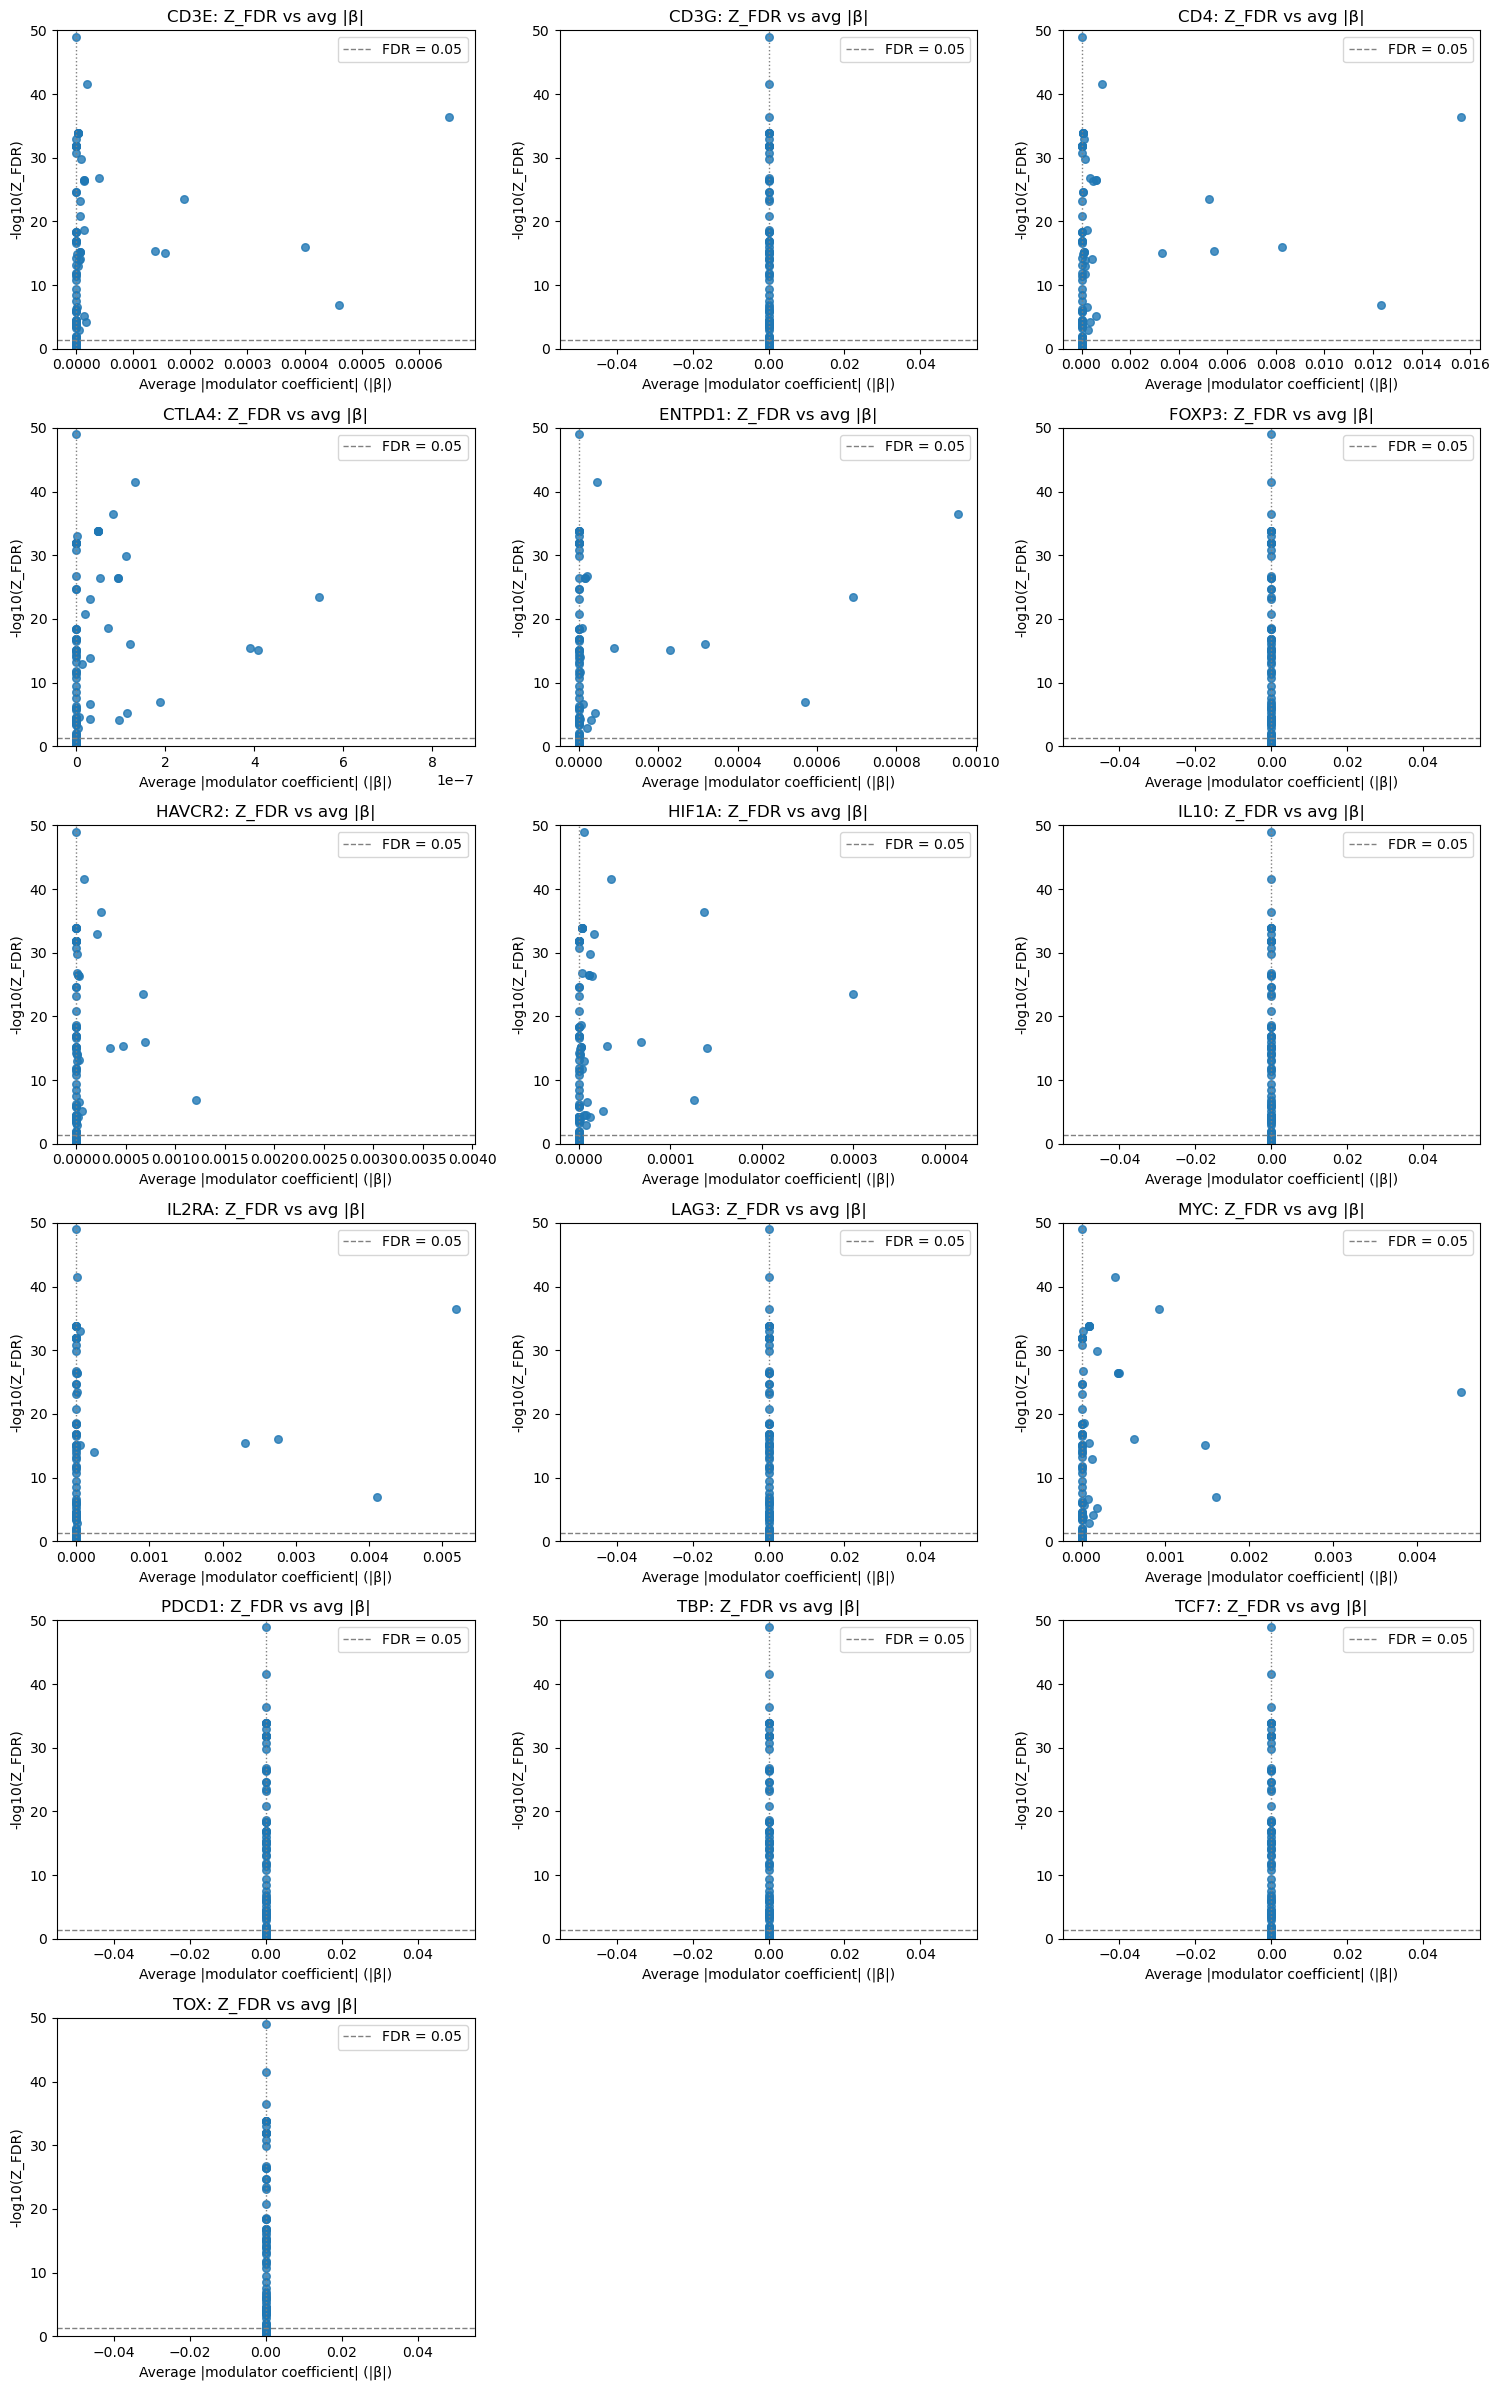

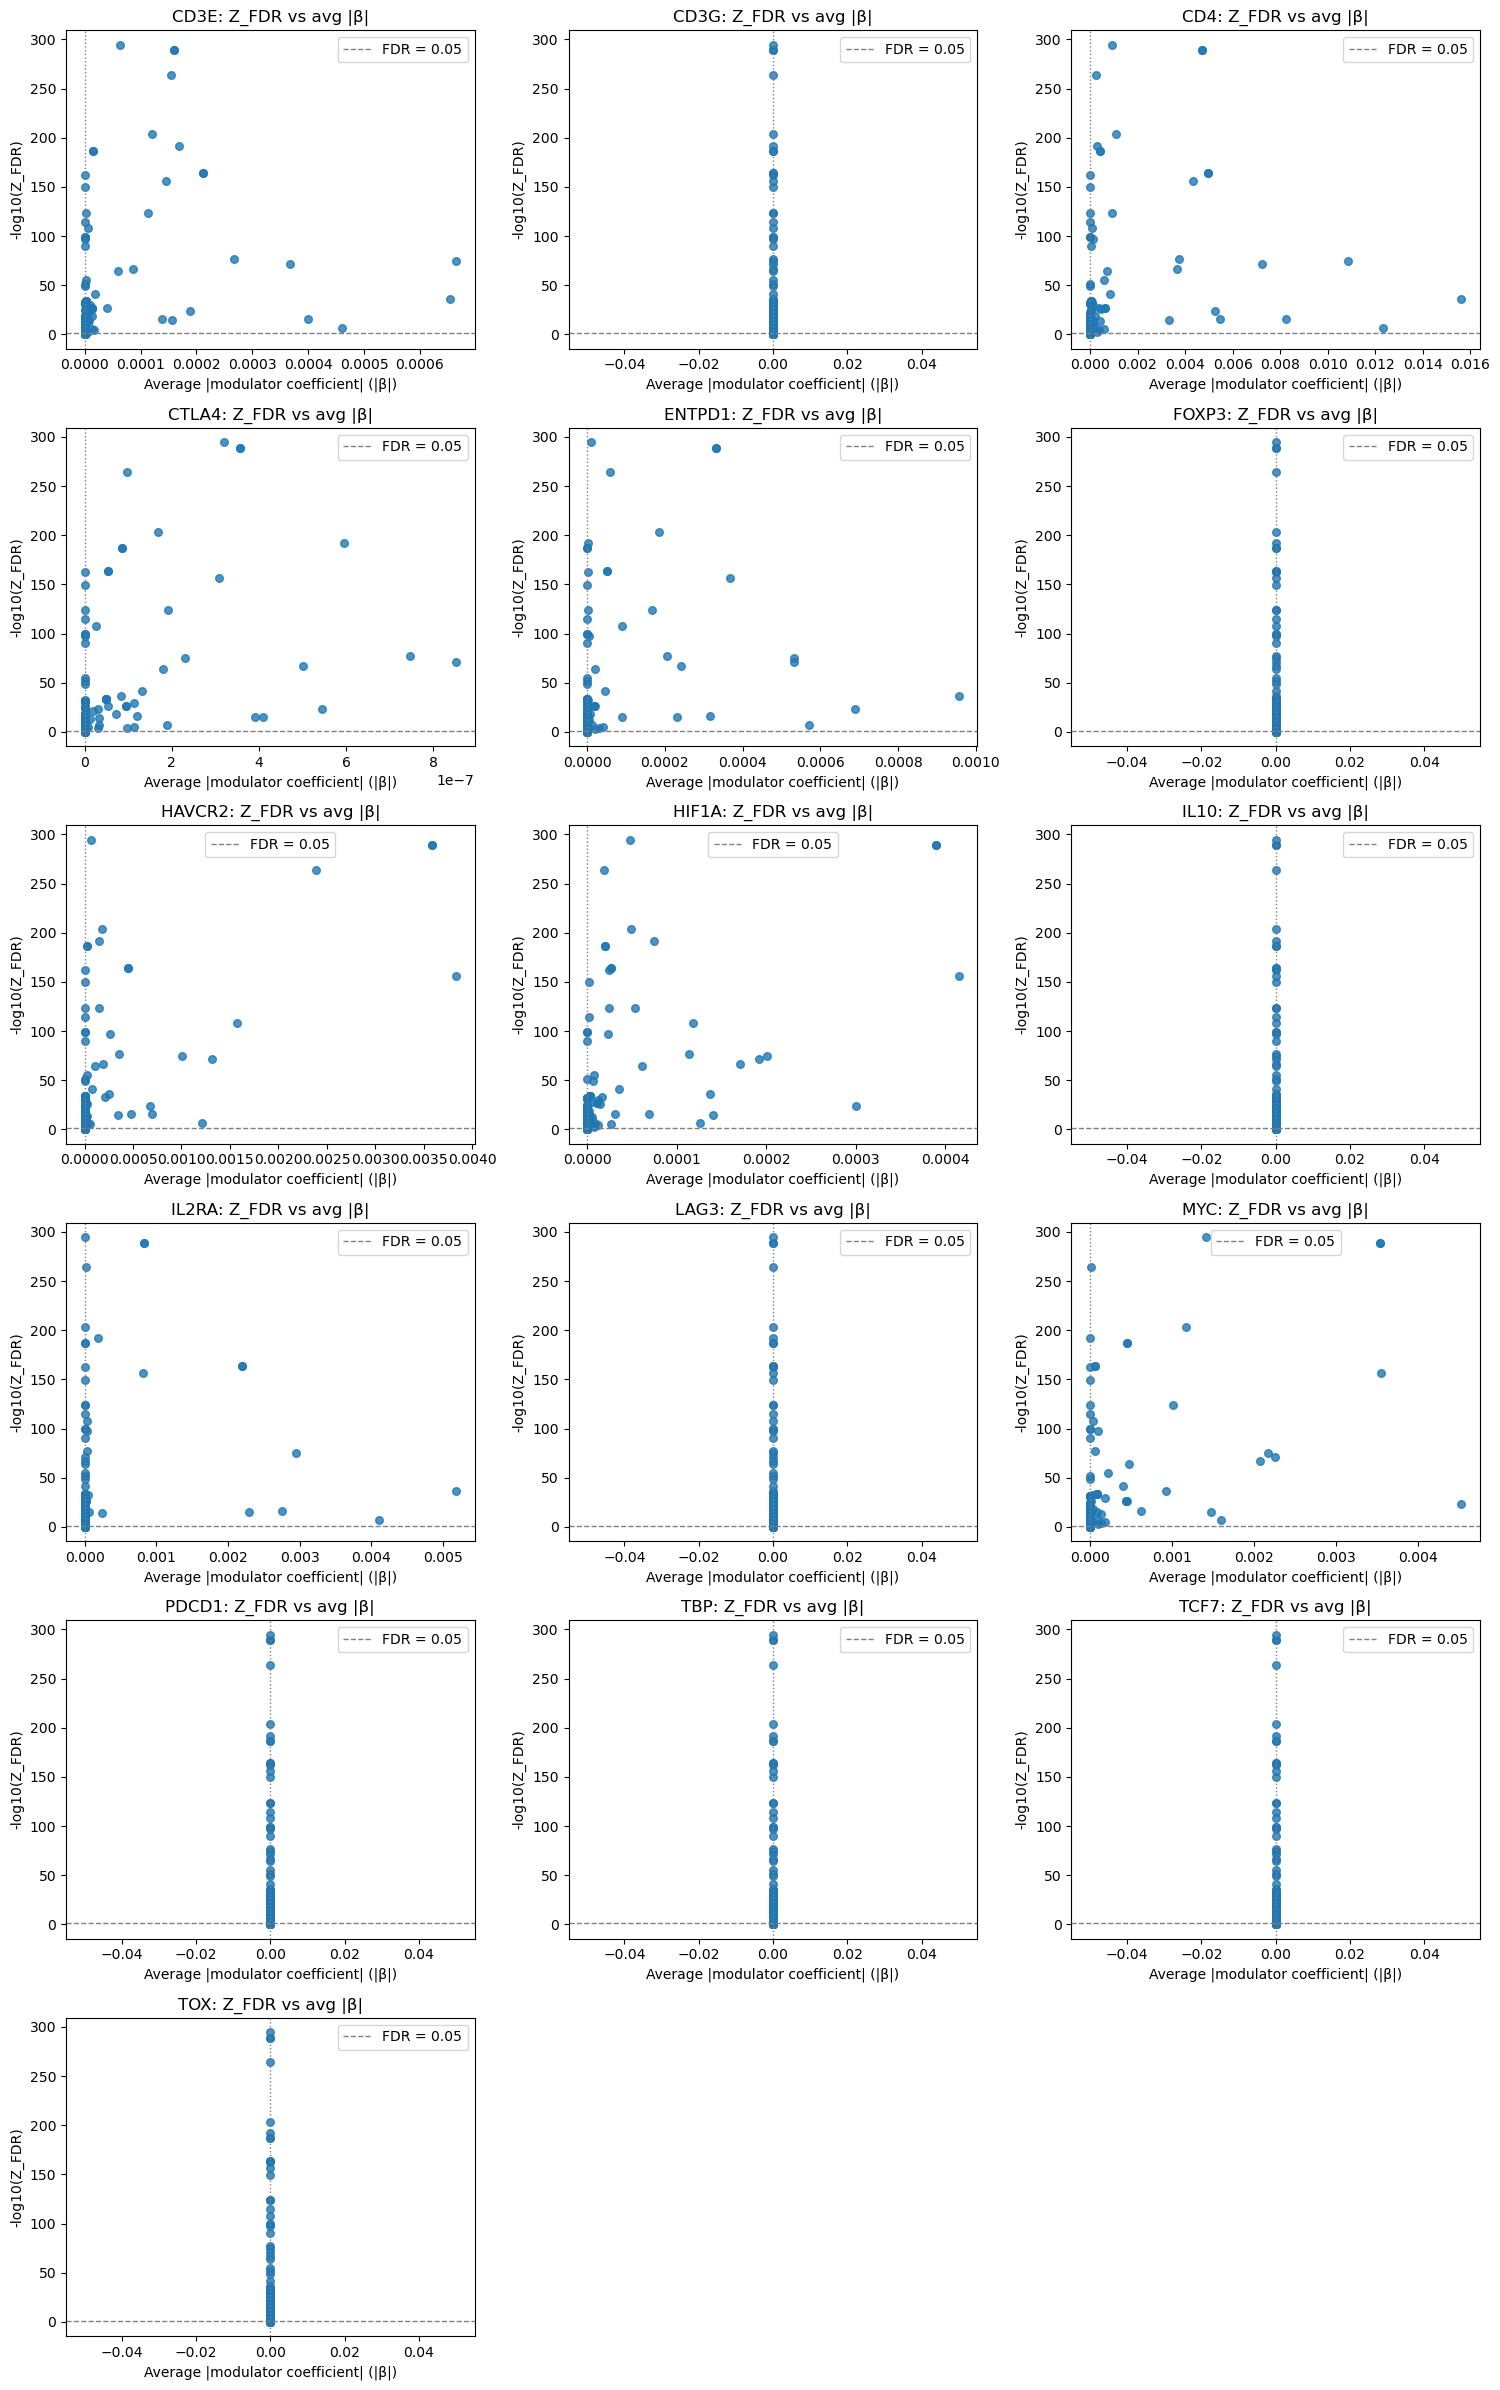

In [23]:
# all genes, Z_FDR, zoomed to the crowded region, no labels
plot_betas_grid(dfs, fdr_col='FDR_np', labels=False)
plt.show()

plot_betas_grid(dfs, fdr_col='Z_FDR', ylim=(0, 50), labels=False)
plt.show()

plot_betas_grid(dfs, fdr_col='Z_FDR', labels=False)
plt.show()



# # a single gene still works with your existing call
# plot_betas(dfs['CD3E'], fdr_col='FDR_np', labels=False, TARGET_GENE='CD3E')
# plt.tight_layout()
# plt.show()